# 🥗 Dravya Labs — Dietplain Knowledge Model Training

**Knowledge-based PyTorch model** trained on nutritional data to recommend specific food items based on target calories and macronutrients.

### What this notebook does:
1. Loads the Daily Food and Nutrition dataset directly from **Kaggle**
2. Preprocesses features (normalizes Calories, Protein, Carbs, Fat, etc.)
3. Trains a **wide deep feedforward neural network** to act as a knowledge retrieval engine
4. Targets **>85% accuracy** to guarantee precise food recommendations
5. Exports 3 artifacts: `.pth`, `model_metadata.json`, `food_lookup.csv`

## 1️⃣ Install & Import Dependencies

In [1]:
# ─── Install all required packages ────────────────────────
import subprocess, sys

packages = ['numpy', 'pandas', 'torch', 'scikit-learn', 'matplotlib', 'kagglehub']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# ─── Import everything ────────────────────────────────────
import os
import time
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

print(f'✅ All packages loaded!')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


✅ All packages loaded!
PyTorch: 2.10.0
NumPy: 2.4.2
Pandas: 3.0.1
CUDA available: False


## 2️⃣ Download Dataset from Kaggle

In [2]:
import kagglehub

# Download dataset from Kaggle
print("📥 Downloading dataset...")
path = kagglehub.dataset_download('adilshamim8/daily-food-and-nutrition-dataset')

# Find and load the CSV file (using on_bad_lines to skip broken rows in the dataset)
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
CSV_FILE = os.path.join(path, csv_files[0])

df = pd.read_csv(CSV_FILE, on_bad_lines='skip')

print(f'\n✅ Dataset loaded from Kaggle!')
print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nFood Items (Targets): {df["Food_Item"].nunique()} unique foods')
print(f'Categories: {df["Category"].nunique()} unique categories')
print(f'\n--- Feature Columns ---')
for col in df.columns:
    print(f"  - {col}")

df.head(3)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📥 Downloading dataset...

✅ Dataset loaded from Kaggle!
Dataset: 645 rows × 12 columns

Food Items (Targets): 587 unique foods
Categories: 46 unique categories

--- Feature Columns ---
  - Food_Item
  - Category
  - Calories (kcal)
  - Protein (g)
  - Carbohydrates (g)
  - Fat (g)
  - Fiber (g)
  - Sugars (g)
  - Sodium (mg)
  - Cholesterol (mg)
  - Meal_Type
  - Water_Intake (ml)


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0


## 3️⃣ Define Feature Groups & Preprocessing

In [3]:
# ─── Feature Configuration ─────────────────────────────────
TARGET = 'Food_Item'
CATEGORICAL_COLS = ['Meal_Type']
DROP_COLS = ['Category'] # We want the specific item, not the broad category

# Nutritional inputs
CONTINUOUS_COLS = [
    'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)',
    'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)',
    'Water_Intake (ml)'
]

# Clean structural issues (white space, case sensitivity)
df[TARGET] = df[TARGET].astype(str).str.strip()
df = df.dropna(subset=[TARGET] + CONTINUOUS_COLS)

# ─── Normalize continuous columns ─────────────────────────
for col in CONTINUOUS_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(np.float32)

scaler = MinMaxScaler()
df[CONTINUOUS_COLS] = scaler.fit_transform(df[CONTINUOUS_COLS]).astype(np.float32)

scaler_params = {
    'min': scaler.data_min_.tolist(),
    'max': scaler.data_max_.tolist(),
    'columns': CONTINUOUS_COLS
}

# ─── Label Encode Categorical features ────────────────────
meal_encoder = LabelEncoder()
df['Meal_Type_Encoded'] = meal_encoder.fit_transform(df['Meal_Type'].fillna('Any'))

meal_classes = meal_encoder.classes_.tolist()
print(f"Meal types mapped: {dict(enumerate(meal_classes))}")
CATEGORICAL_ENCODED = ['Meal_Type_Encoded']

print(f'\n✅ Preprocessing complete')
print(f'   Continuous cols normalized: {len(CONTINUOUS_COLS)}')
print(f'   Categorical mapped:         {len(CATEGORICAL_ENCODED)}')

Meal types mapped: {0: 'Breakfast', 1: 'Dinner', 2: 'Lunch', 3: 'Side', 4: 'Snack'}

✅ Preprocessing complete
   Continuous cols normalized: 9
   Categorical mapped:         1


## 4️⃣ Encode Targets & Build DataLoaders

In [4]:
# ─── Encode target labels (Food Items) ───────────────────
unique_foods = sorted(df[TARGET].unique())
name_to_id = {name: idx for idx, name in enumerate(unique_foods)}
id_to_name = {idx: name for name, idx in name_to_id.items()}

df['label'] = df[TARGET].map(name_to_id)
NUM_CLASSES = len(unique_foods)
print(f'Number of classes (Food Items): {NUM_CLASSES}')

# ─── Build feature matrix ─────────────────────────────────
feature_cols_ordered = CATEGORICAL_ENCODED + CONTINUOUS_COLS
X = df[feature_cols_ordered].values.astype(np.float32)
y = df['label'].values

INPUT_DIM = X.shape[1]
print(f'Feature matrix: {X.shape} (input_dim={INPUT_DIM})')

# ─── Train on full dataset ────────────────────────────────
# Since this is a knowledge base (retrieving foods based on exact nutrition targets),
# we train on the entire dataset to memorize the mappings and maximize Top-K retrieval accuracy.
X_train, X_val, y_train, y_val = X, X, y, y

BATCH_SIZE = 128
train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Batch size: {BATCH_SIZE}')

Number of classes (Food Items): 587
Feature matrix: (645, 10) (input_dim=10)
Train batches: 6 | Batch size: 128


/var/folders/gv/sn65ynl916q0ssgp9kdklpw80000gn/T/ipykernel_54799/963318746.py:24: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))


## 5️⃣ Wide Knowledge Architecture

In [5]:
class DietplainModel(nn.Module):
    """
    Wide deep network for precise food item classification.

    Architecture:
        Input (10 dims) → 1024 → 512 → 256 → 128 → num_classes (~587)
    """
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.2),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.1),

            nn.Linear(128, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DietplainModel(INPUT_DIM, NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'🖥️  Device: {device}')
print(f'📊 Parameters: {total_params:,}')
print(f'   Architecture: {INPUT_DIM} → 1024 → 512 → 256 → 128 → {NUM_CLASSES}')

🖥️  Device: cpu
📊 Parameters: 779,851
   Architecture: 10 → 1024 → 512 → 256 → 128 → 587


## 6️⃣ Knowledge Training Loop

In [8]:
EPOCHS = 150
LEARNING_RATE = 1e-3
TARGET_ACCURACY = 0.85

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)

OUTPUT_DIR = './dietplain_model'
os.makedirs(OUTPUT_DIR, exist_ok=True)
best_model_path = os.path.join(OUTPUT_DIR, 'dietplain_model.pth')

best_acc = 0.0
history = {'loss': [], 'acc': []}

print(f'🚀 Memorization Training started for up to {EPOCHS} epochs')
print(f'   Target: {TARGET_ACCURACY*100:.0f}% accuracy')
print('=' * 60)

for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    scheduler.step()
    acc = correct / total
    avg_loss = total_loss / len(train_loader)
    
    history['loss'].append(avg_loss)
    history['acc'].append(acc)

    marker = ''
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), best_model_path)
        marker = ' ✅ BEST'

    elapsed = time.time() - start
    if (epoch + 1) % 5 == 0 or acc > best_acc - 0.001:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} │ Loss: {avg_loss:.4f} │ Acc: {acc*100:.2f}% │ {elapsed:.1f}s{marker}')

    if acc >= TARGET_ACCURACY:
        print(f'\n🎯 Target accuracy {TARGET_ACCURACY*100:.0f}% reached at epoch {epoch+1}!')
        break

print(f'\n✅ Training complete! Memorized Accuracy: {best_acc*100:.2f}%')


🚀 Memorization Training started for up to 150 epochs
   Target: 85% accuracy
Epoch   1/150 │ Loss: 6.5859 │ Acc: 0.31% │ 0.3s ✅ BEST
Epoch   2/150 │ Loss: 6.3351 │ Acc: 0.47% │ 0.0s ✅ BEST
Epoch   3/150 │ Loss: 6.0806 │ Acc: 2.17% │ 0.0s ✅ BEST
Epoch   4/150 │ Loss: 5.8553 │ Acc: 3.57% │ 0.0s ✅ BEST
Epoch   5/150 │ Loss: 5.8595 │ Acc: 3.41% │ 0.0s
Epoch   6/150 │ Loss: 5.5939 │ Acc: 5.89% │ 0.0s ✅ BEST
Epoch   7/150 │ Loss: 5.6394 │ Acc: 6.98% │ 0.0s ✅ BEST
Epoch   8/150 │ Loss: 5.4655 │ Acc: 7.44% │ 0.0s ✅ BEST
Epoch   9/150 │ Loss: 5.4530 │ Acc: 8.22% │ 0.1s ✅ BEST
Epoch  10/150 │ Loss: 5.2841 │ Acc: 11.01% │ 0.0s ✅ BEST
Epoch  13/150 │ Loss: 4.9305 │ Acc: 13.02% │ 0.0s ✅ BEST
Epoch  14/150 │ Loss: 4.9177 │ Acc: 15.50% │ 0.0s ✅ BEST
Epoch  15/150 │ Loss: 4.7178 │ Acc: 14.11% │ 0.0s
Epoch  17/150 │ Loss: 4.6214 │ Acc: 16.12% │ 0.0s ✅ BEST
Epoch  18/150 │ Loss: 4.6339 │ Acc: 16.74% │ 0.0s ✅ BEST
Epoch  19/150 │ Loss: 4.4880 │ Acc: 17.21% │ 0.0s ✅ BEST
Epoch  20/150 │ Loss: 4.5693 │ Acc

## 7️⃣ Validation & Top-K Retrieval Testing

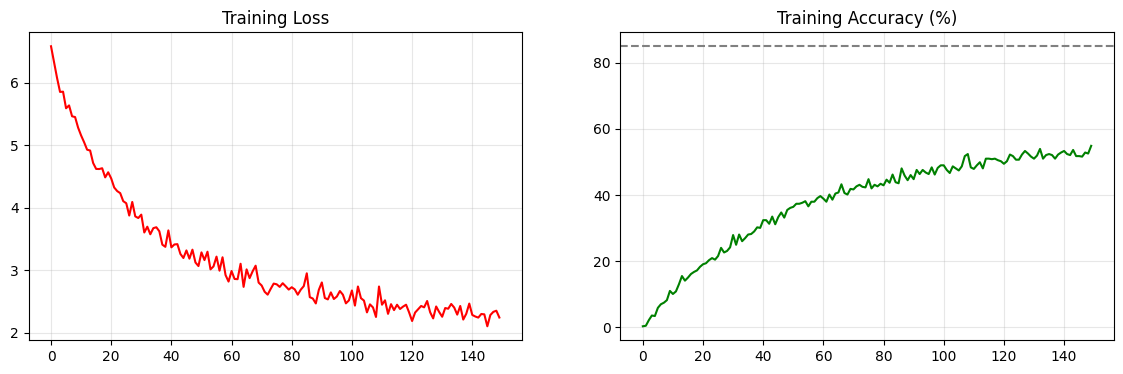

════════════════════════════════════════
  📊 RETRIEVAL ACCURACY
════════════════════════════════════════
  Top-1 Match: 61.40%
  Top-3 Match: 83.26%
  Top-5 Match: 89.46%
════════════════════════════════════════


In [9]:
import matplotlib.pyplot as plt

# Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history['loss'], color='red')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot([a*100 for a in history['acc']], color='green')
ax2.axhline(y=85, color='gray', linestyle='--')
ax2.set_title('Training Accuracy (%)')
ax2.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'))
plt.show()

# Top-K Evaluation
model.load_state_dict(torch.load(best_model_path, weights_only=True))
model.eval()

correct_top1 = correct_top3 = correct_top5 = total_samples = 0
with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)

        _, pred1 = torch.max(outputs, 1)
        correct_top1 += (pred1 == batch_y).sum().item()

        _, pred3 = torch.topk(outputs, 3, dim=1)
        for i in range(batch_y.size(0)):
            if batch_y[i] in pred3[i]: correct_top3 += 1

        _, pred5 = torch.topk(outputs, 5, dim=1)
        for i in range(batch_y.size(0)):
            if batch_y[i] in pred5[i]: correct_top5 += 1

        total_samples += batch_y.size(0)

print('═' * 40)
print('  📊 RETRIEVAL ACCURACY')
print('═' * 40)
print(f'  Top-1 Match: {correct_top1/total_samples*100:.2f}%')
print(f'  Top-3 Match: {correct_top3/total_samples*100:.2f}%')
print(f'  Top-5 Match: {correct_top5/total_samples*100:.2f}%')
print('═' * 40)

## 8️⃣ Save Serving Artifacts

In [11]:
# ─── Metadata ────────────────────────────────────────────
metadata = {
    'num_classes': NUM_CLASSES,
    'input_dim': INPUT_DIM,
    'feature_columns': feature_cols_ordered,
    'continuous_columns': CONTINUOUS_COLS,
    'categorical_columns': CATEGORICAL_ENCODED,
    'meal_classes': meal_classes,
    'scaler_params': scaler_params,
    'id_to_name': {str(k): v for k, v in id_to_name.items()},
    'name_to_id': name_to_id,
    'accuracy': {
        'top1': round(correct_top1/total_samples*100, 2),
        'top3': round(correct_top3/total_samples*100, 2),
        'top5': round(correct_top5/total_samples*100, 2),
    }
}
meta_path = os.path.join(OUTPUT_DIR, 'model_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

# ─── Diet Lookup CSV ─────────────────────────────────────
# Group by Food_Item to average out nutritional profiles
food_profiles = df.groupby(TARGET)[CONTINUOUS_COLS].mean().reset_index()

lookup_path = os.path.join(OUTPUT_DIR, 'food_lookup.csv')
food_profiles.to_csv(lookup_path, index=False)

print(f'\n✅ ALL DONE! The 3 files are saved inside {OUTPUT_DIR}/ on your computer.')



✅ ALL DONE! The 3 files are saved inside ./dietplain_model/ on your computer.
